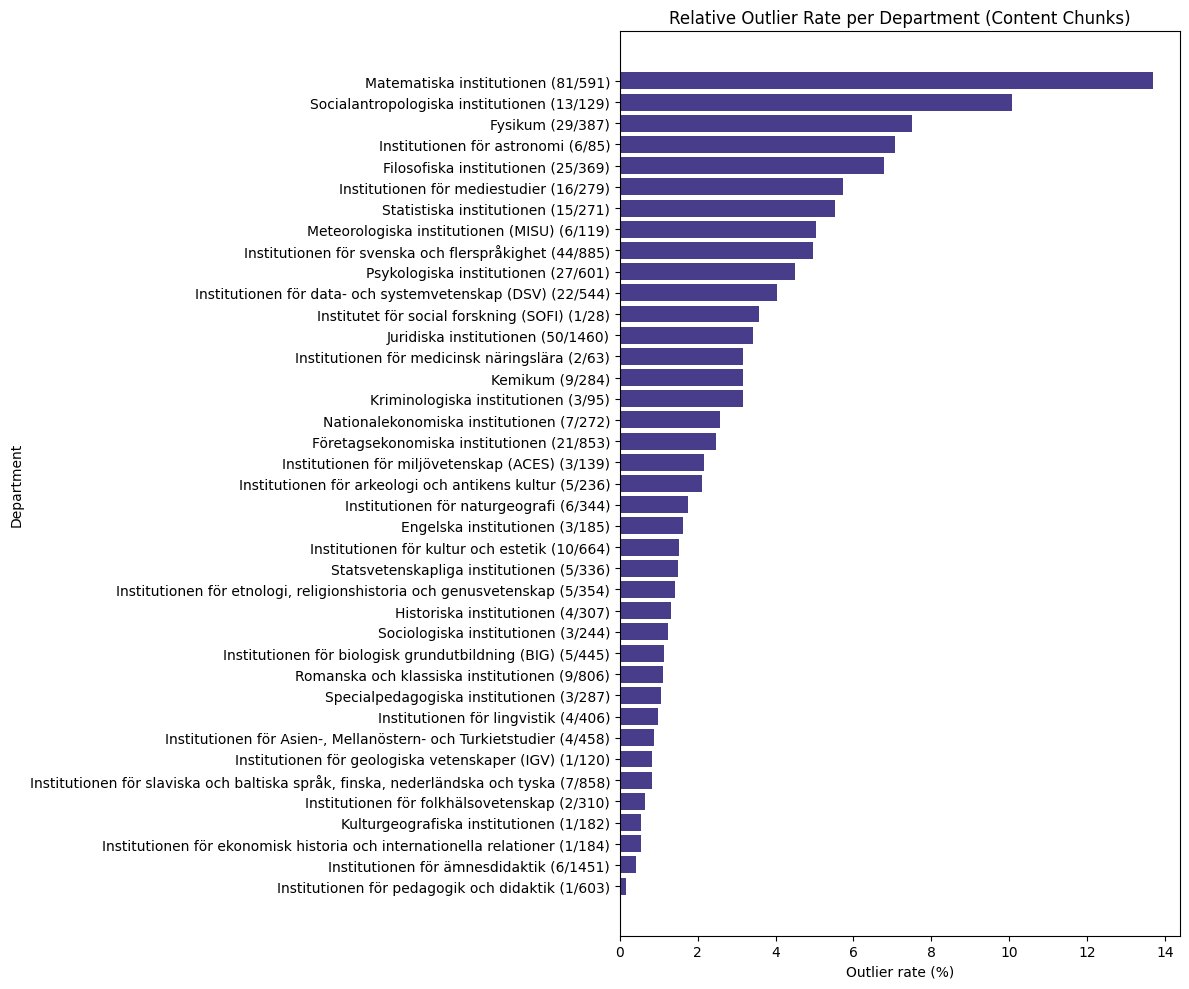

In [ ]:
import json
import matplotlib.pyplot as plt

with open('data/content.sbert.similarities.json', 'r') as f:
    data = json.load(f)

with open('data/outliers.content.json', 'r') as f:
    outliers = json.load(f)

with open('data/SU.departments.json', 'r') as f:
    dept = json.load(f)

with open('data/SU.filtered.json', 'r') as f:
    corpus = json.load(f)

course_departments = {course['CourseCode']: course['Department'] for course in corpus['Course-list']}

dept_chunk_counts = {}
for course_code, course in data.items():
    department = course_departments.get(course_code, 'Unknown')
    dept_chunk_counts[department] = dept_chunk_counts.get(department, 0) + len(course['chunks'])

dept_outlier_counts = {}
for outlier in outliers:
    dept_code = course_departments.get(outlier['course_code'], 'Unknown')
    dept_outlier_counts[dept_code] = dept_outlier_counts.get(dept_code, 0) + 1

relative_counts = {}
for dept_code, out_count in dept_outlier_counts.items():
    chunk_count = dept_chunk_counts.get(dept_code, 0)
    if chunk_count > 0:
        relative_counts[dept_code] = out_count / chunk_count  # fraction

pairs = sorted(relative_counts.items(), key=lambda x: x[1], reverse=True)

if pairs:
    dept_codes = [p[0] for p in pairs]
    rates_pct = [p[1] * 100 for p in pairs]  # percent
    labels = [
        f"{dept.get(code, code)} ({dept_outlier_counts.get(code, 0)}/{dept_chunk_counts.get(code, 0)})"
        for code in dept_codes
    ]

    plt.figure(figsize=(12, 10))
    plt.barh(labels, rates_pct, color='darkslateblue')
    plt.xlabel('Outlier rate (%)')
    plt.ylabel('Department')
    plt.title('Relative Outlier Rate per Department (Content Chunks)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


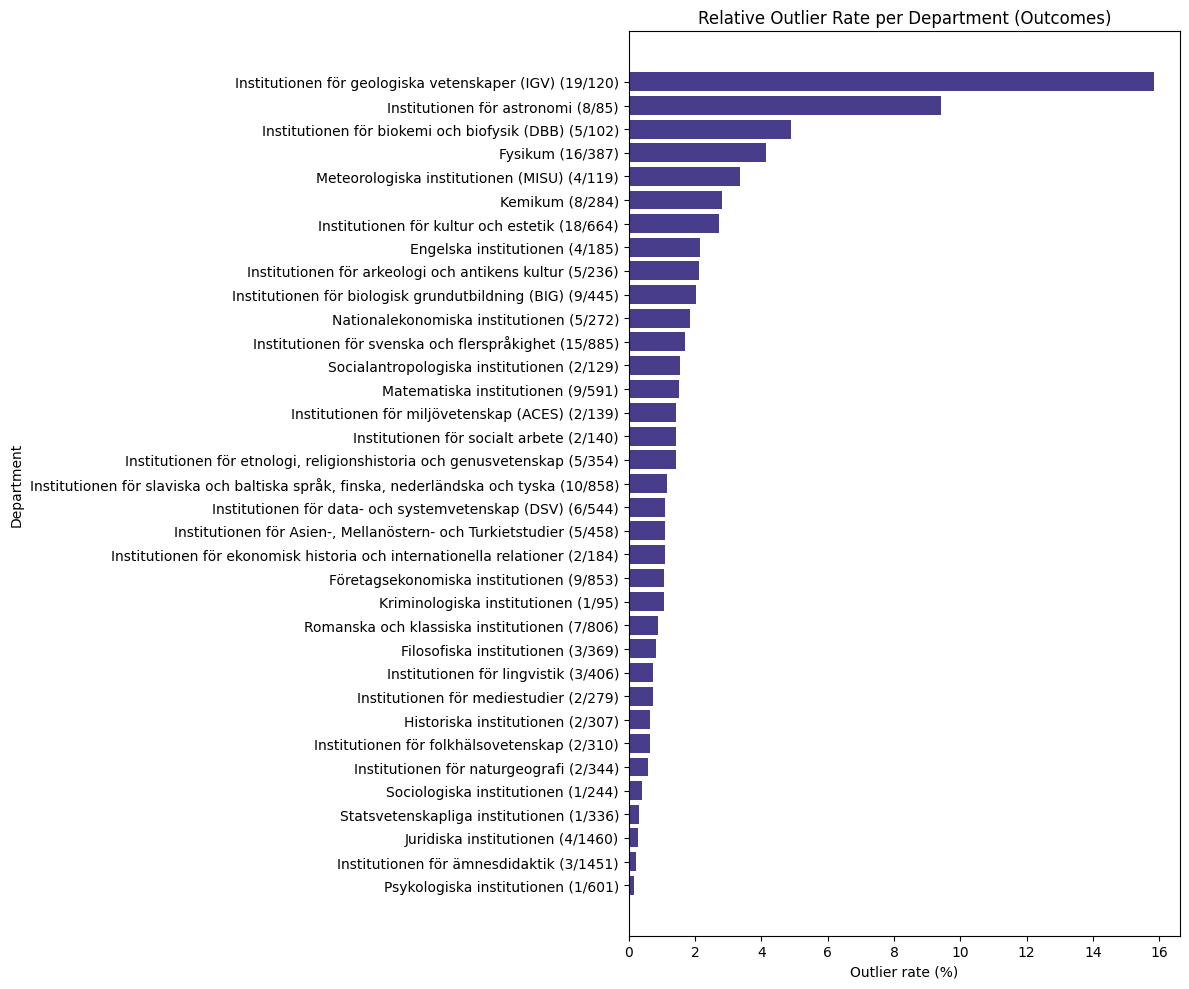

In [ ]:
import json
import matplotlib.pyplot as plt

with open('data/outcome.sbert.similarities.json', 'r') as f:
    data = json.load(f)
with open('data/outliers.outcome.json', 'r') as f:
    outliers = json.load(f)
with open('data/SU.departments.json', 'r') as f:
    dept = json.load(f)
with open('data/SU.filtered.json', 'r') as f:
    corpus = json.load(f)

course_departments = {course['CourseCode']: course['Department'] for course in corpus['Course-list']}

# Count content_chunks per department
dept_chunk_counts = {}
for course_code, course in data.items():
    department = course_departments.get(course_code, 'Unknown')
    dept_chunk_counts[department] = dept_chunk_counts.get(department, 0) + len(course['content_chunks'])

# Count outliers per department
dept_outlier_counts = {}
for outlier in outliers:
    dept_code = course_departments.get(outlier['course_code'], 'Unknown')
    dept_outlier_counts[dept_code] = dept_outlier_counts.get(dept_code, 0) + 1

# Compute relative outlier rate per department
relative_counts = {}
for dept_code, out_count in dept_outlier_counts.items():
    chunk_count = dept_chunk_counts.get(dept_code, 0)
    if chunk_count > 0:
        relative_counts[dept_code] = out_count / chunk_count

pairs = sorted(relative_counts.items(), key=lambda x: x[1], reverse=True)

if pairs:
    dept_codes = [p[0] for p in pairs]
    rates_pct = [p[1] * 100 for p in pairs]
    labels = [
        f"{dept.get(code, code)} ({dept_outlier_counts.get(code, 0)}/{dept_chunk_counts.get(code, 0)})"
        for code in dept_codes
    ]

    plt.figure(figsize=(12, 10))
    plt.barh(labels, rates_pct, color='darkslateblue')
    plt.xlabel('Outlier rate (%)')
    plt.ylabel('Department')
    plt.title('Relative Outlier Rate per Department (Outcomes)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()